# Automobile Price Prediction Models

## Objective
This notebook develops and compares regression models for predicting automobile price from vehicle specifications and segment membership.

## Analytical question
Which regression model provides the most accurate predictions of automobile price based on vehicle characteristics?


## Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42


## Load clustered data

This notebook uses the dataset produced by Notebook 02. It includes the cleaned automobile data and the K-Means cluster assignment.


In [2]:
file_path = Path('../data/processed/automobiles_with_clusters.csv')

if not file_path.exists():
    raise FileNotFoundError(
        f'File not found: {file_path.resolve()}\n'
        'Run Notebook 02 first to create automobiles_with_clusters.csv.'
    )

df = pd.read_csv(file_path)

if 'price' not in df.columns:
    raise ValueError('The dataset must contain a price column.')

print(f'Loaded {df.shape[0]} rows and {df.shape[1]} columns.')
display(df.head())


Loaded 201 rows and 27 columns.


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price,cluster
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,2
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,2
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,1
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,2
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,1


## Feature selection

Price is the target variable. The selected predictors include numeric vehicle characteristics and categorical attributes. The cluster assignment is handled as a categorical feature because cluster labels have no natural order.


In [3]:
target = 'price'

numeric_features = [
    'symboling', 'normalized_losses', 'wheel_base', 'length', 'width',
    'height', 'curb_weight', 'engine_size', 'bore', 'stroke',
    'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg'
]

categorical_features = [
    'make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style',
    'drive_wheels', 'engine_location', 'engine_type', 'num_of_cylinders',
    'fuel_system', 'cluster'
]

numeric_features = [col for col in numeric_features if col in df.columns]
categorical_features = [col for col in categorical_features if col in df.columns]
feature_columns = numeric_features + categorical_features

if not feature_columns:
    raise ValueError('No predictor columns were found.')

X = df[feature_columns].copy()
y = df[target].copy()

print(f'Predictors: {len(feature_columns)}')
print(f'Numeric predictors: {len(numeric_features)}')
print(f'Categorical predictors: {len(categorical_features)}')


Predictors: 26
Numeric predictors: 15
Categorical predictors: 11


## Train-test split

The test set is held back before preprocessing and fitting. All transformations are placed inside model pipelines to prevent data leakage.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Training observations: {X_train.shape[0]}')
print(f'Test observations: {X_test.shape[0]}')


Training observations: 160
Test observations: 41


## Preprocessing pipeline

Numeric features are median-imputed and standardized. Categorical features are filled with their most frequent value and one-hot encoded.


In [5]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ]
)


## Model training and evaluation

Linear regression, random forest, and gradient boosting are compared on the same held-out test set. The RMSE calculation below uses `np.sqrt(mean_squared_error(...))`, which works with current and older scikit-learn versions.


In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        random_state=RANDOM_STATE
    )
}

fitted_models = {}
predictions = {}
results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    fitted_models[model_name] = pipeline
    predictions[model_name] = y_pred

    mse = mean_squared_error(y_test, y_pred)

    results.append({
        'model': model_name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_test, y_pred)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('RMSE')
    .reset_index(drop=True)
)

display(results_df.round(2))


,model,MAE,RMSE,R2
0,Gradient Boosting,1703.60,2547.75,0.95
1,Random Forest,1881.26,2885.48,0.93
2,Linear Regression,1930.06,3119.54,0.92


In [8]:
best_model_name = results_df.loc[0, 'model']
best_row = results_df.loc[0]

summary = f"""### Model comparison findings

- **{best_model_name}** had the lowest test-set RMSE at **${best_row['RMSE']:,.0f}**.
- Its mean absolute error was **${best_row['MAE']:,.0f}** and its R-squared value was **{best_row['R2']:.3f}**.
- Results are based on the held-out test set, which was not used to fit the models.
"""
display(Markdown(summary))


### Model comparison findings

- **Gradient Boosting** had the lowest test-set RMSE at **$2,548**.
- Its mean absolute error was **$1,704** and its R-squared value was **0.947**.
- Results are based on the held-out test set, which was not used to fit the models.


## Model comparison visualization

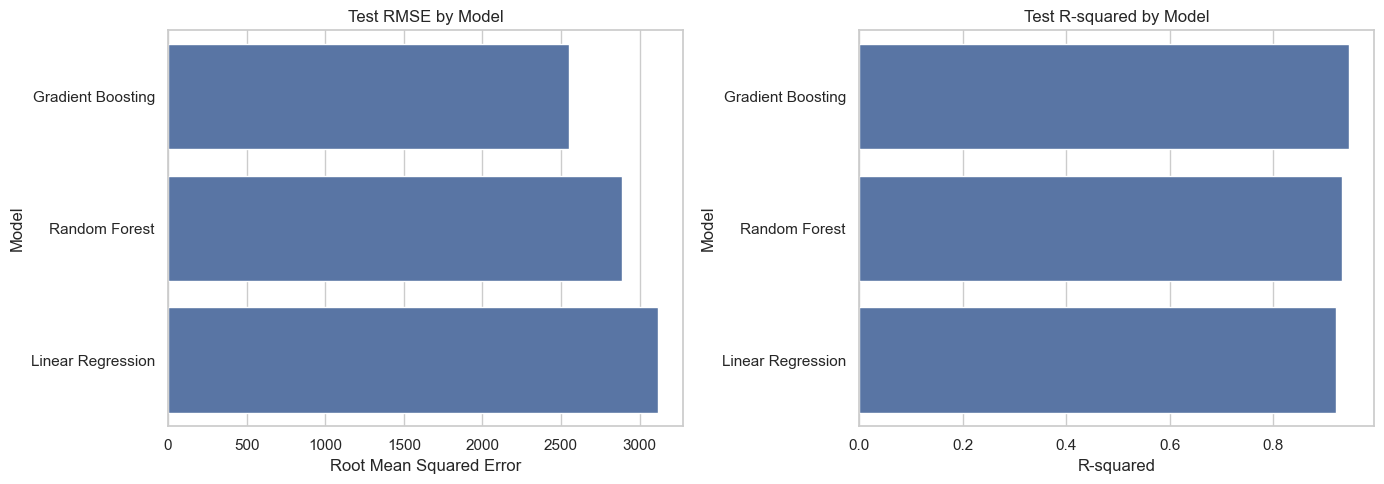

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='RMSE', y='model', ax=axes[0])
axes[0].set_title('Test RMSE by Model')
axes[0].set_xlabel('Root Mean Squared Error')
axes[0].set_ylabel('Model')

sns.barplot(data=results_df, x='R2', y='model', ax=axes[1])
axes[1].set_title('Test R-squared by Model')
axes[1].set_xlabel('R-squared')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()


## Actual versus predicted prices

Points close to the diagonal indicate predictions close to the observed automobile prices.


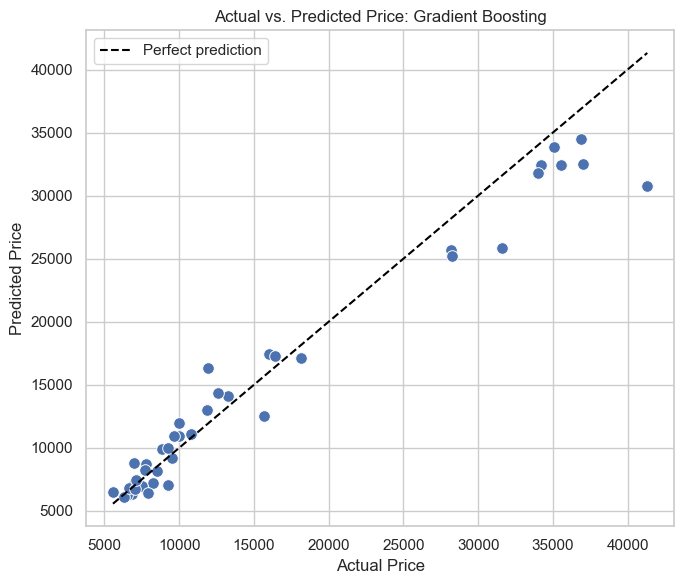

In [11]:
best_predictions = predictions[best_model_name]

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_predictions, s=70)

lower = min(y_test.min(), best_predictions.min())
upper = max(y_test.max(), best_predictions.max())
plt.plot([lower, upper], [lower, upper], linestyle='--', color='black', label='Perfect prediction')

plt.title(f'Actual vs. Predicted Price: {best_model_name}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()


## Feature importance

Permutation importance shows how much test performance changes when a feature is randomly shuffled. Larger values indicate features that were more useful to the selected model.


In [13]:
best_pipeline = fitted_models[best_model_name]
permutation = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring='neg_root_mean_squared_error'
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': permutation.importances_mean,
    'importance_std': permutation.importances_std
}).sort_values('importance', ascending=False)

display(importance_df.head(12).round(3))


,feature,importance,importance_std
7,engine_size,3539.200,364.998
25,cluster,2184.006,425.270
6,curb_weight,1656.252,294.092
4,width,1099.532,147.294
15,make,637.148,113.752
11,horsepower,545.395,91.666
13,city_mpg,493.234,105.971
14,highway_mpg,241.531,54.861
19,body_style,175.825,92.855
2,wheel_base,153.528,62.808


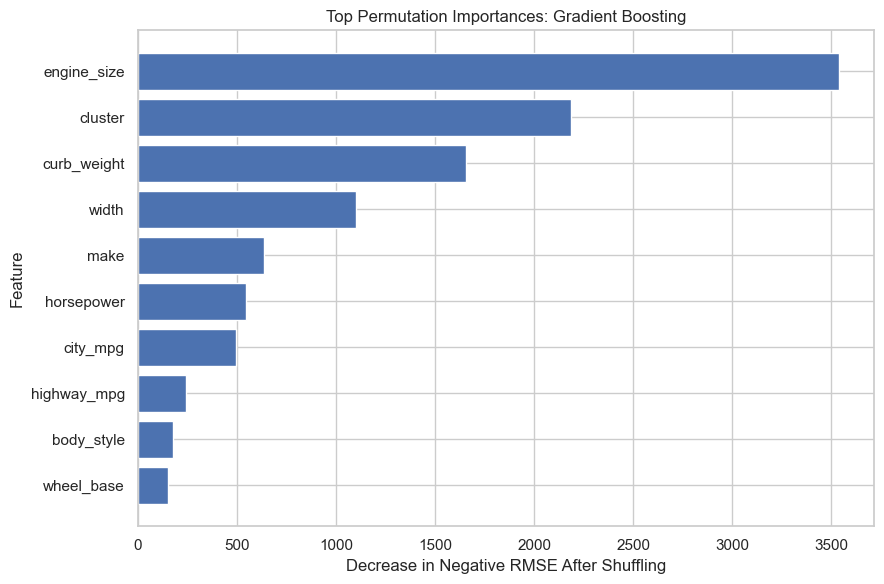

In [14]:
top_importance = importance_df.head(10).sort_values('importance')

plt.figure(figsize=(9, 6))
plt.barh(top_importance['feature'], top_importance['importance'])
plt.title(f'Top Permutation Importances: {best_model_name}')
plt.xlabel('Decrease in Negative RMSE After Shuffling')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Cluster-feature evaluation

The best model is run with and without the cluster feature to test whether the K-Means segmentation adds predictive value beyond the other vehicle characteristics.


In [16]:
categorical_without_cluster = [
    col for col in categorical_features if col != 'cluster'
]

preprocessor_without_cluster = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_without_cluster)
    ]
)

best_model = models[best_model_name]
pipeline_without_cluster = Pipeline(steps=[
    ('preprocessor', preprocessor_without_cluster),
    ('model', best_model)
])

pipeline_without_cluster.fit(X_train, y_train)
pred_without_cluster = pipeline_without_cluster.predict(X_test)

with_cluster_rmse = results_df.loc[
    results_df['model'] == best_model_name, 'RMSE'
] .iloc[0]
without_cluster_rmse = np.sqrt(mean_squared_error(y_test, pred_without_cluster))

cluster_effect = pd.DataFrame({
    'model_version': ['With cluster', 'Without cluster'],
    'RMSE': [with_cluster_rmse, without_cluster_rmse],
    'MAE': [
        results_df.loc[results_df['model'] == best_model_name, 'MAE'].iloc[0],
        mean_absolute_error(y_test, pred_without_cluster)
    ],
    'R2': [
        results_df.loc[results_df['model'] == best_model_name, 'R2'].iloc[0],
        r2_score(y_test, pred_without_cluster)
    ]
})

display(cluster_effect.round(2))


,model_version,RMSE,MAE,R2
0,With cluster,2547.75,1703.60,0.95
1,Without cluster,2554.28,1709.14,0.95


In [17]:
rmse_change = without_cluster_rmse - with_cluster_rmse

if rmse_change > 0:
    effect_text = 'reduced RMSE'
elif rmse_change < 0:
    effect_text = 'increased RMSE'
else:
    effect_text = 'did not change RMSE'

summary = f"""### Cluster-feature finding

- Adding the cluster variable {effect_text} by **${abs(rmse_change):,.0f}** for the selected model.
- This comparison shows whether segmentation adds useful predictive information beyond the other vehicle characteristics.
"""
display(Markdown(summary))


### Cluster-feature finding

- Adding the cluster variable reduced RMSE by **$7** for the selected model.
- This comparison shows whether segmentation adds useful predictive information beyond the other vehicle characteristics.


## Export model results

In [18]:
output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

metrics_file = output_dir / 'regression_model_metrics.csv'
importance_file = output_dir / 'regression_feature_importance.csv'

results_df.to_csv(metrics_file, index=False)
importance_df.to_csv(importance_file, index=False)

print(f'Saved: {metrics_file.resolve()}')
print(f'Saved: {importance_file.resolve()}')


Saved: E:\GitHub\FinalTlabz\data\processed\regression_model_metrics.csv
Saved: E:\GitHub\FinalTlabz\data\processed\regression_feature_importance.csv


## Regression conclusion

In [19]:
top_features = ', '.join(importance_df.head(3)['feature'].tolist())

summary = f"""### Summary of findings

- Three regression models were evaluated on the same train-test split.
- The best test-set performance came from **{best_model_name}**, with RMSE of **${best_row['RMSE']:,.0f}**, MAE of **${best_row['MAE']:,.0f}**, and R-squared of **{best_row['R2']:.3f}**.
- The most influential original features in the permutation analysis were **{top_features}**.
- Model metrics and feature-importance results were exported successfully: **{metrics_file.exists() and importance_file.exists()}**.
"""
display(Markdown(summary))


### Summary of findings

- Three regression models were evaluated on the same train-test split.
- The best test-set performance came from **Gradient Boosting**, with RMSE of **$2,548**, MAE of **$1,704**, and R-squared of **0.947**.
- The most influential original features in the permutation analysis were **engine_size, cluster, curb_weight**.
- Model metrics and feature-importance results were exported successfully: **True**.


### Interpretation

The regression comparison shows that automobile price can be predicted from a combination of technical specifications and categorical vehicle characteristics. The preferred model is selected using held-out test performance rather than training accuracy alone.

The feature-importance results identify the original vehicle characteristics that contributed most to the selected model's predictions. These are predictive relationships in this dataset and should not be interpreted as proof of causation.

The cluster comparison tests whether the vehicle segments from Notebook 02 add information beyond the individual specifications. The result is evaluated by its impact on test-set error.
